In [29]:
from PIL import Image
import numpy as np
# load
im = Image.open('materials_numpy/2007_000042.png')

im = np.array(im)

im[im == 255] = 0
print(np.unique(im))
from torch.nn.functional import one_hot
import torch

im = torch.from_numpy(im).to(torch.int64)

#im = one_hot(torch.from_numpy(im).to(torch.int64), 15).permute(2, 0, 1)

im.shape

[0 7]


torch.Size([512, 482])

In [30]:
def acos_safe(x, eps=1e-4):
    sign = torch.sign(x)
    slope = np.arccos(1-eps) / eps
    return torch.where(abs(x) <= 1-eps,
                    torch.acos(x),
                    torch.acos(sign * (1 - eps)) - slope*sign*(abs(x) - 1 + eps))

In [31]:
def spectral_angles_pytorch(data, members, eps=1e-7):
    
    assert members.shape[1] == data.shape[2], 'Matrix dimensions are not aligned.'

    # Normalize members with epsilon for numerical stability
    m = members / (torch.sqrt(torch.einsum('ij,ij->i', members, members))[:, None] + eps)

    # Compute norms with epsilon
    norms = torch.sqrt(torch.einsum('ijk,ijk->ij', data, data)) + eps

    # Compute dot products
    dots = torch.einsum('ijk,mk->ijm', data, m)

    # Apply softmax to angles
    dots = torch.clamp(dots / norms[:, :, np.newaxis], -1 + eps, 1 + eps)

    return -torch.acos(dots).permute(2, 0, 1) 
 

In [104]:
hs = np.load('materials_numpy/2007_000042.npy')
hs = torch.from_numpy(hs).to(torch.float32)
hs = hs / 100.0

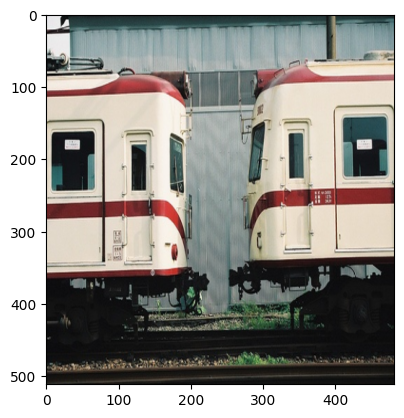

In [33]:
im2 = Image.open('materials_numpy/2007_000042as.png').convert('RGB')
im2 = np.array(im2)

im2 = im2 / 255.0

im2 = torch.from_numpy(im2).to(torch.float32)
import matplotlib.pyplot as plt
plt.imshow(im2)

In [37]:
import torch
import torch.nn as nn
import segmentation_models_pytorch.losses as losses

class SimpleConvNet(nn.Module):
    def __init__(self):
        super(SimpleConvNet, self).__init__()
        self.members_param = torch.nn.Parameter(torch.randn(15, 31))
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 31, kernel_size=3, stride=1, padding=1)

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x.clamp_(0, 1)

        x = spectral_angles_pytorch(x.squeeze().permute(1,2,0), self.members_param)
        
        return x

net = SimpleConvNet()

optimizer = torch.optim.Adam(net.parameters(), lr=0.1)

criterion =  losses.FocalLoss("multiclass", ignore_index=None, gamma=3)

for epoch in range(10):
    optimizer.zero_grad()

    outputs = net(im2.permute(2, 0, 1).unsqueeze(0).float())

    print(outputs.shape)

    probs = torch.softmax(outputs, dim=0)

    print(probs.shape)


    print(probs[:,50,50])
    print(torch.argmax(probs[:,50,50]))
    # argmax
    pred = torch.argmax(probs, dim=0)

    print(pred.shape)
    print(pred.unique())


    import matplotlib.pyplot as plt
    fig = plt.figure()
    ax1 = fig.add_subplot(121)
    ax1.imshow(pred.detach())
    ax2 = fig.add_subplot(122)
    print(outputs.detach().unsqueeze(0).shape)
    ax2.imshow(outputs.detach().squeeze(0)[7,:,:])
    plt.show()



    loss = criterion(outputs.float().unsqueeze(0), im.unsqueeze(0))

    print(loss)

    loss.backward()  # Backpropagation

    optimizer.step()

    #clip members_param between 0 and 1
    net.members_param.data.clamp_(0, 1)

    


AssertionError: Matrix dimensions are not aligned.

In [111]:
import torch
import torch.nn as nn

class SpectralAnglesLayer(nn.Module):
    def __init__(self, eps=1e-6):
        super(SpectralAnglesLayer, self).__init__()
        self.eps = eps
        self.members = nn.Parameter(torch.randn(15, 31))
        torch.nn.init.xavier_uniform_(self.members)

    def forward(self, data):
        """
        Args
        ----
        data: torch.Tensor
            A tensor of shape (batch, channels, height, width)
        """
        # Normalize the members
        m = self.members / (torch.sqrt(torch.einsum('ij,ij->i', self.members, self.members))[:, None] + self.eps)

        # Reshape data to (batch, height*width, channels) for easier computation
        batch, channels, height, width = data.shape
        data = data.view(batch, channels, height * width).permute(0, 2, 1)

        # Compute norms with epsilon
        norms = torch.sqrt(torch.einsum('bij,bij->bi', data, data)) + self.eps

        # Compute dot products
        dots = torch.einsum('bij,mj->bim', data, m)

        # Apply softmax to angles
        dots = torch.clamp(dots / norms[:, :, None], -1 + self.eps, 1 + self.eps)

        # Compute angles and permute back to (batch, members, height, width)
        angles = -torch.acos(dots).permute(0, 2, 1).view(batch, -1, height, width)

        return angles



# Example usage:
# members = <initialize your members tensor here>
layer = SpectralAnglesLayer()
# result = layer(data)


In [105]:
hs = hs.permute(2, 0, 1).unsqueeze(0)


In [112]:
# Initialize data and members with parameters that will be updated
#data = torch.randn(512, 482, 31, requires_grad=True)
#members = torch.randn(15, 31, requires_grad=True)

# Convert data and members to parameters
members_param = torch.nn.Parameter(torch.randn(15, 31))



# Optimizer (for example, using SGD)
optimizer = torch.optim.Adam(layer.parameters(), lr=0.01)
# Loss function
loss_function = nn.CrossEntropyLoss()


# Training loop
for i in range(100):
    optimizer.zero_grad()  # Zero the gradients

    # Compute angles
    probs = layer(hs)

    loss = loss_function(probs.float(), im.unsqueeze(0))
    print(loss)
    loss.backward()  # Backpropagation


    optimizer.step()

    #clip members_param between 0 and 1
    layer.members.data.clamp_(0, 1)
    


tensor(2.7232, grad_fn=<NllLoss2DBackward0>)
tensor(2.7060, grad_fn=<NllLoss2DBackward0>)
tensor(2.6972, grad_fn=<NllLoss2DBackward0>)
tensor(2.6882, grad_fn=<NllLoss2DBackward0>)
tensor(2.6794, grad_fn=<NllLoss2DBackward0>)
tensor(2.6707, grad_fn=<NllLoss2DBackward0>)
tensor(2.6623, grad_fn=<NllLoss2DBackward0>)
tensor(2.6541, grad_fn=<NllLoss2DBackward0>)
tensor(2.6461, grad_fn=<NllLoss2DBackward0>)
tensor(2.6383, grad_fn=<NllLoss2DBackward0>)
tensor(2.6308, grad_fn=<NllLoss2DBackward0>)
tensor(2.6236, grad_fn=<NllLoss2DBackward0>)
tensor(2.6166, grad_fn=<NllLoss2DBackward0>)
tensor(2.6097, grad_fn=<NllLoss2DBackward0>)
tensor(2.6031, grad_fn=<NllLoss2DBackward0>)
tensor(2.5967, grad_fn=<NllLoss2DBackward0>)
tensor(2.5907, grad_fn=<NllLoss2DBackward0>)
tensor(2.5851, grad_fn=<NllLoss2DBackward0>)
tensor(2.5800, grad_fn=<NllLoss2DBackward0>)
tensor(2.5760, grad_fn=<NllLoss2DBackward0>)
tensor(2.5738, grad_fn=<NllLoss2DBackward0>)
tensor(2.5735, grad_fn=<NllLoss2DBackward0>)
tensor(2.5

torch.Size([15, 512, 482])


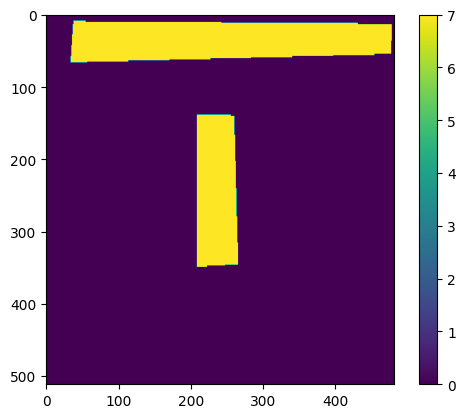

In [113]:
# Final angle calculation
probs = layer(hs) 
probs = probs.squeeze()
print(probs.shape)


probs = torch.softmax(probs, dim=0)

# argmax
pred = torch.argmax(probs, dim=0)


import matplotlib.pyplot as plt
plt.imshow(pred.detach().numpy())
plt.colorbar()

In [96]:
probs[:,1,1]

tensor([0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667,
        0.0667, 0.0667, 0.0667, 0.0667, 0.0667, 0.0667],
       grad_fn=<SelectBackward0>)

In [55]:
probs.shape, torch.argmax(probs[:, 50, 50], dim=0),probs[:, 50, 50], torch.sum(probs[:, 50, 50], dim=0)

(torch.Size([15, 512, 482]),
 tensor(7),
 tensor([0.0608, 0.0619, 0.0562, 0.0633, 0.0628, 0.0588, 0.0573, 0.1843, 0.0590,
         0.0496, 0.0578, 0.0588, 0.0617, 0.0464, 0.0613],
        grad_fn=<SelectBackward0>),
 tensor(1.0000, grad_fn=<SumBackward1>))

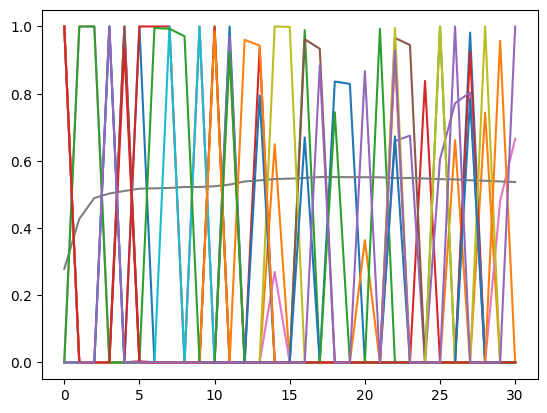

In [56]:
plt.plot(layer.members.detach().numpy().T)

In [57]:
members_param[7,:]

tensor([-0.4107,  1.0864,  0.2666,  0.5380,  0.3172,  0.1720, -0.6661, -1.2135,
        -0.5541,  0.4301, -1.2808, -0.7852, -0.3022, -0.0644, -0.6981, -0.0758,
        -1.2147, -0.3345, -0.2414,  1.2257,  0.0919,  0.5800, -1.4107, -0.4264,
        -2.1750, -0.4824,  0.1870,  2.0052,  2.4563, -1.6304, -0.1991],
       grad_fn=<SliceBackward0>)

In [327]:
hs[50, 50, :].numpy().shape, s2.shape

((31,), torch.Size([31]))

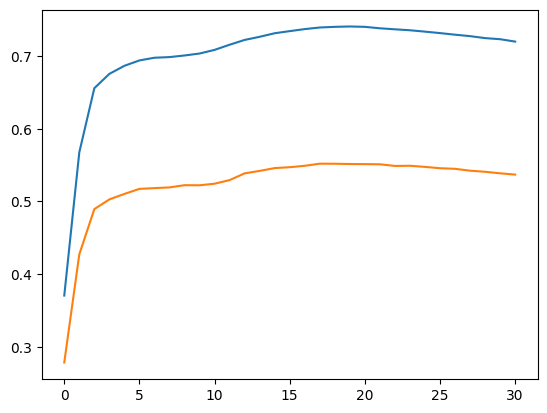

In [59]:
s1 = hs[50, 50, :]
s2 = layer.members.detach()[7,:]

plt.plot(s1)
plt.plot(s2)

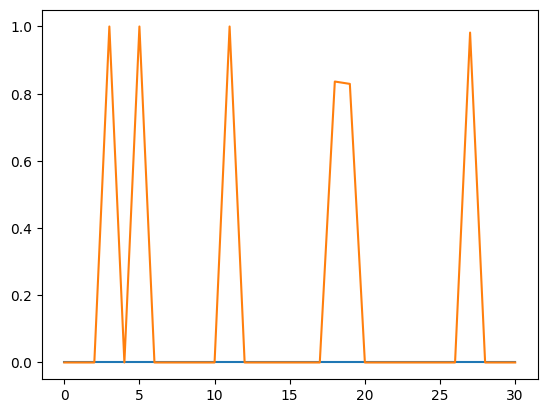

In [92]:
s1 = hs[1, 1, :]
s2 = layer.members.detach()[0,:]

plt.plot(s1)
plt.plot(s2)

In [87]:

def SAM_pytorch(s1, s2):
    """
    Computes the spectral angle mapper between two vectors (in radians).

    Parameters:
        s1: `numpy array`
            The first vector.

        s2: `numpy array`
            The second vector.

    Returns: `float`
            The angle between vectors s1 and s2 in radians.
    """
    s1 = s1 + 1e-6
    try:
        s1_norm = torch.sqrt(torch.dot(s1, s1))
        s2_norm = torch.sqrt(torch.dot(s2, s2))
        sum_s1_s2 = torch.dot(s1, s2)
        angle = torch.acos(sum_s1_s2 / ((s1_norm * s2_norm)  + 1e-6))
    except ValueError:
        # python math don't like when acos is called with
        # a value very near to 1
        return 0.0
    return angle

SAM_pytorch(s1,s2)

tensor(1.1518)

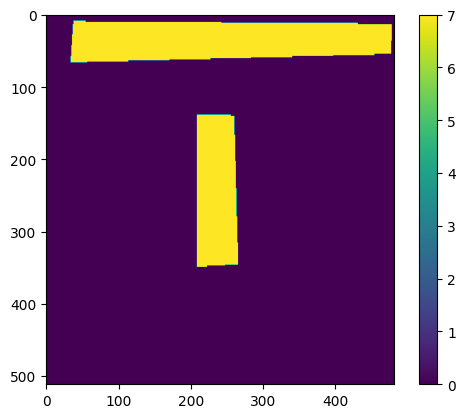

In [117]:
plt.imshow(im)
plt.colorbar()